In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, auc,
                             precision_score, recall_score, f1_score, accuracy_score,roc_auc_score,pairwise_distances,log_loss)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import joblib as joblib
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [2]:
data = pd.read_csv("/Users/sanakulkarni/BEEG-Epilepsy-Dataset/dataset/BEED_Data.csv")

In [3]:
data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0


In [4]:
data.tail()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
7995,-9,-4,-7,2,-9,-14,-7,12,-5,-3,-2,-2,-12,-5,4,1,3
7996,-8,-4,-7,1,-8,-14,-7,12,-6,-3,-2,-3,-15,-4,4,1,3
7997,-6,-5,-7,1,-8,-14,-7,12,-7,-3,-2,-4,-16,-4,3,1,3
7998,-5,-6,-6,1,-8,-13,-7,13,-7,-2,-3,-5,-15,-4,3,0,3
7999,-4,-7,-5,2,-8,-12,-7,14,-6,0,-3,-6,-13,-4,2,0,3


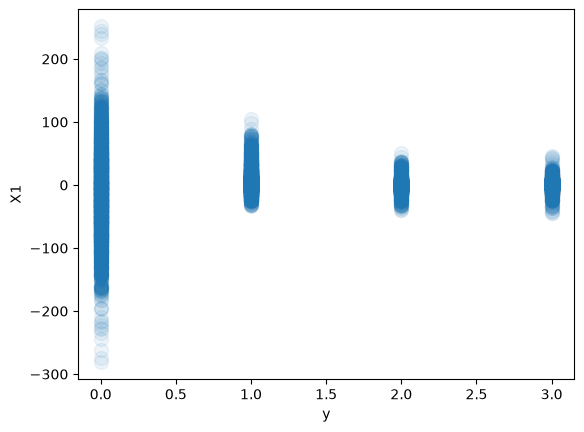

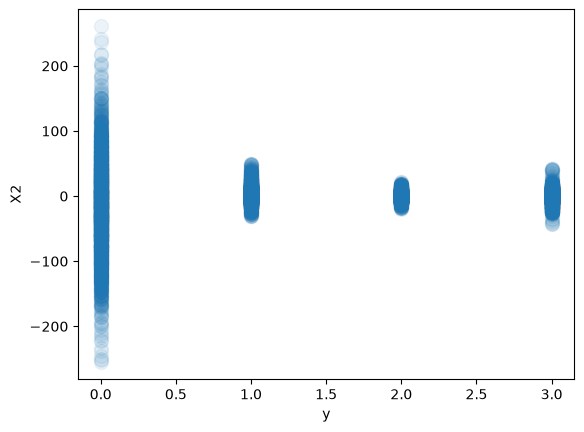

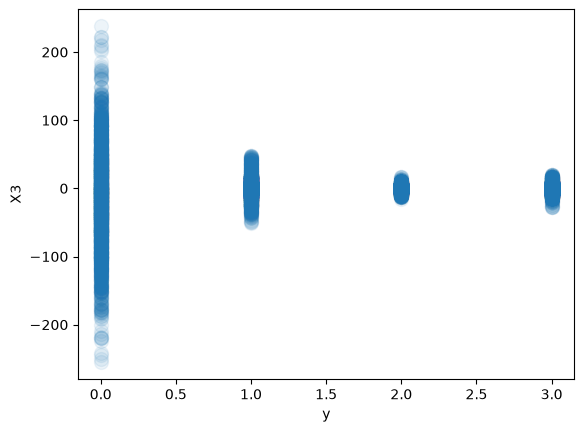

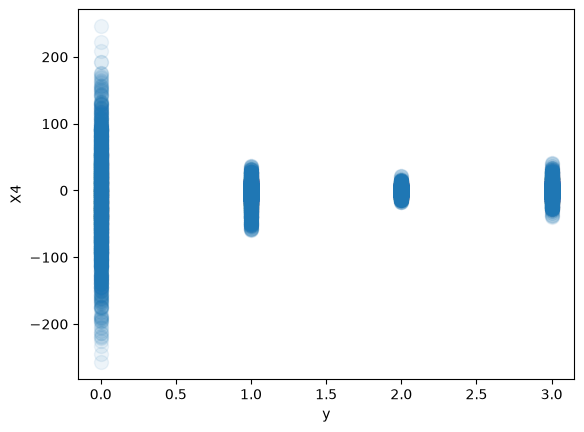

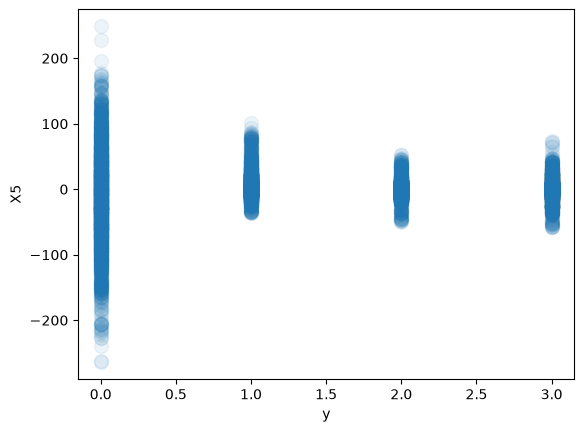

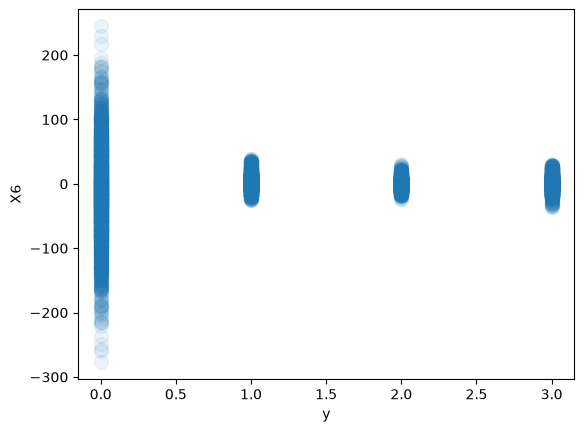

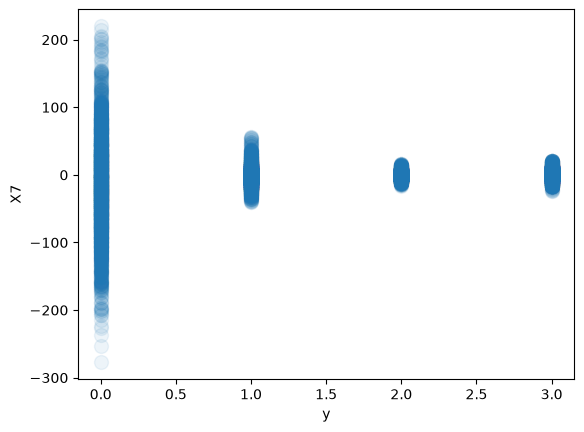

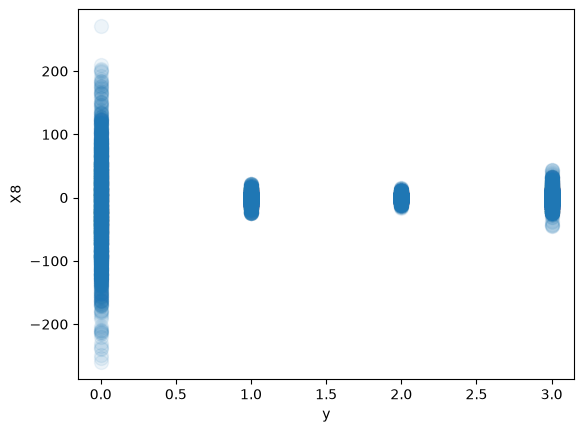

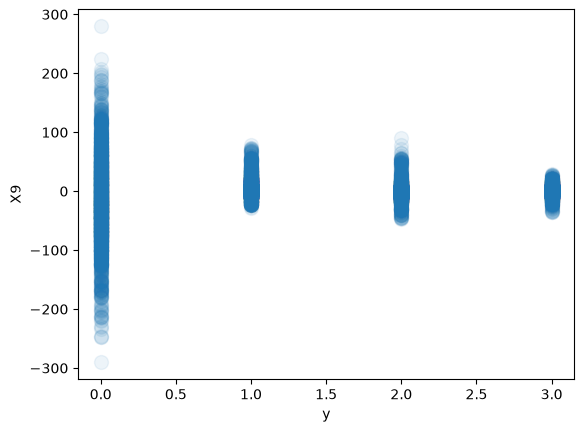

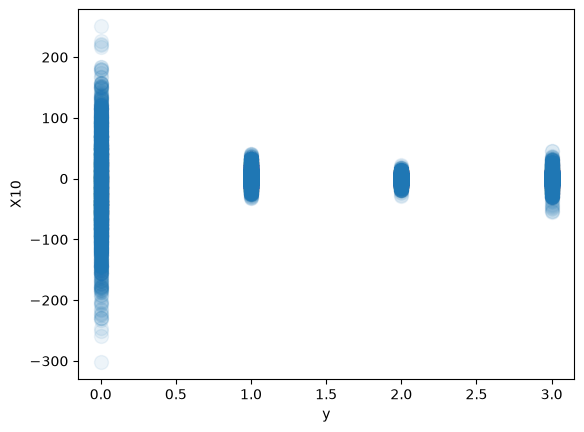

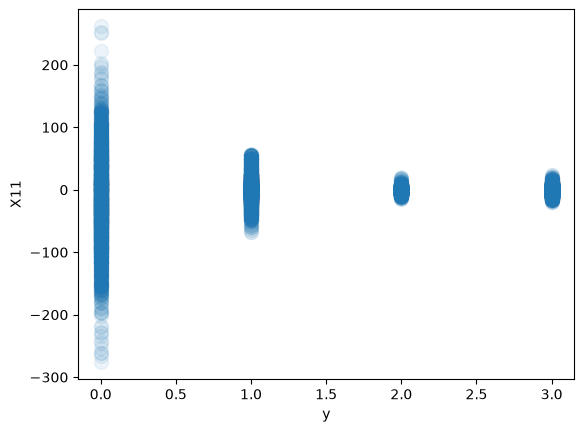

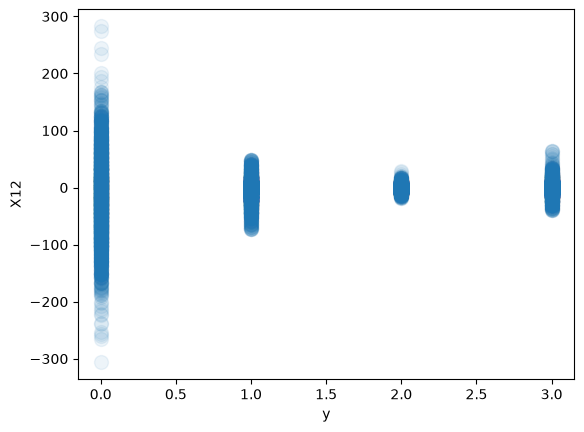

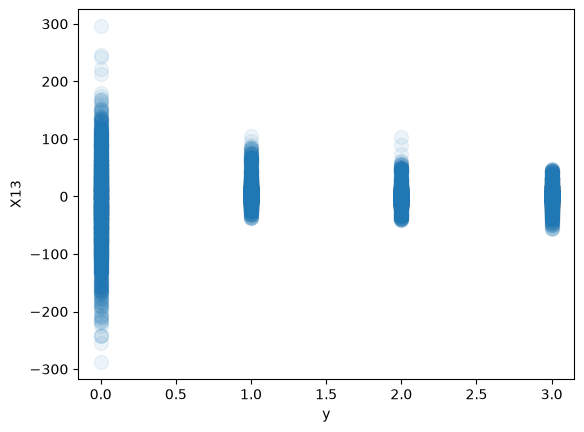

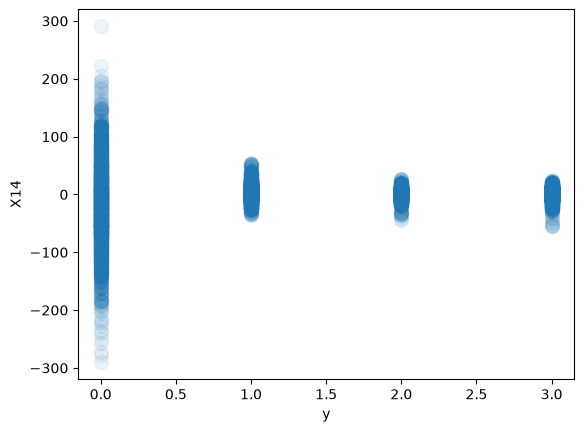

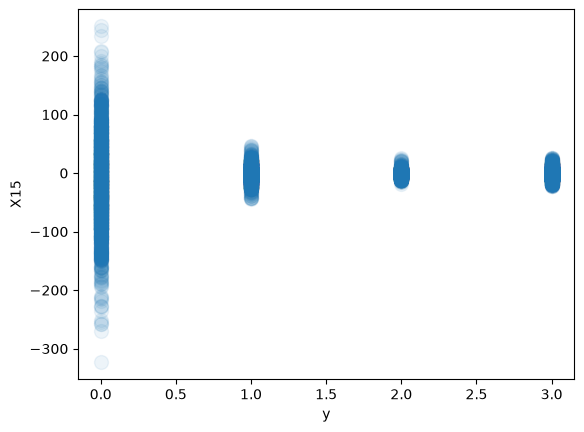

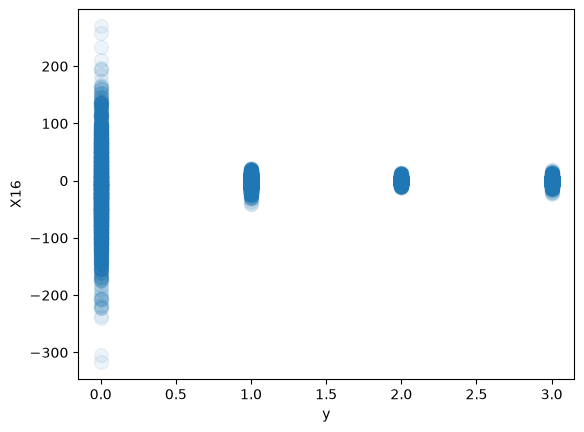

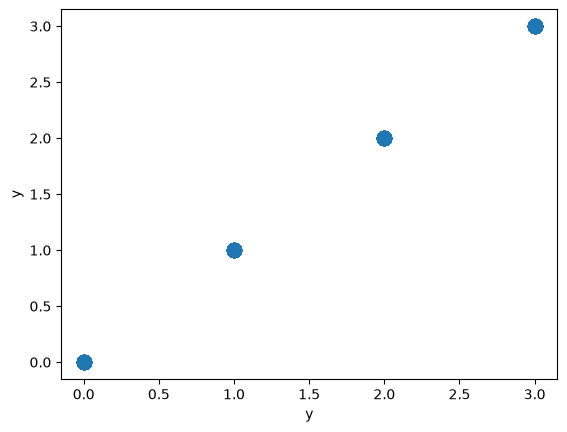

In [12]:
for col in data.columns:
    data.plot(kind = 'scatter', x = 'y',y = col,s = 100 ,alpha = 0.08)
    plt.show()


In [13]:
corr_matrix = data.corr()
corr_matrix['y'].sort_values(ascending=False)


y      1.000000
X16    0.143114
X15    0.137789
X12    0.137027
X4     0.124639
X14    0.120986
X11    0.118392
X8     0.115265
X7     0.114569
X13    0.113355
X10    0.110543
X3     0.109810
X6     0.107511
X2     0.102064
X9     0.099789
X1     0.098804
X5     0.091489
Name: y, dtype: float64

In [14]:
data["y"].value_counts()

y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64

In [16]:
data.isnull().sum()

X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
y      0
dtype: int64

In [17]:
X = data.drop("y", axis =1)
y = data["y"]

In [20]:
model1 = LogisticRegression(max_iter=1000,class_weight="balanced")

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [22]:
scaler = StandardScaler()

# 4. Fit and transform the training data
# This calculates the mean and std dev, then applies the scaling formula
X_train_scaled = scaler.fit_transform(X_train)

# 5. Transform the testing data
# Crucial: Use .transform(), NOT .fit_transform() to prevent data leakage
X_test_scaled = scaler.transform(X_test)

In [40]:
model1.fit(X_train,y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [24]:
lr_pred = model1.predict(X_test)

/Users/sanakulkarni/BEEG-Epilepsy-Dataset/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [41]:
print(classification_report(y_test, lr_pred))

print("Accuracy:", accuracy_score(y_test, lr_pred))

confusion_matrix(y_test, lr_pred)

              precision    recall  f1-score   support

           0       0.49      0.53      0.51       400
           1       0.41      0.75      0.53       400
           2       0.34      0.16      0.22       400
           3       0.33      0.19      0.24       400

    accuracy                           0.41      1600
   macro avg       0.39      0.41      0.37      1600
weighted avg       0.39      0.41      0.37      1600

Accuracy: 0.40875


array([[212,  90,  46,  52],
       [ 36, 301,  36,  27],
       [ 97, 159,  64,  80],
       [ 91, 190,  42,  77]])

In [42]:
rf_model = RandomForestClassifier(n_estimators=500,
        criterion='gini',
        max_depth=7,
        max_features='sqrt',
        random_state=1)

In [43]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: 

In [44]:
rf_pred = rf_model.predict(X_test)

In [45]:
print(classification_report(y_test, rf_pred))

print("Accuracy:", accuracy_score(y_test, rf_pred))


confusion_matrix(y_test, rf_pred)

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.77      0.81      0.79       400
           2       0.60      0.85      0.71       400
           3       0.82      0.44      0.57       400

    accuracy                           0.78      1600
   macro avg       0.80      0.78      0.77      1600
weighted avg       0.80      0.78      0.77      1600

Accuracy: 0.775


array([[397,   3,   0,   0],
       [  0, 324,  60,  16],
       [  0,  35, 342,  23],
       [  0,  57, 166, 177]])

In [79]:
param_grid = {
    'classifier__n_estimators': [875,887],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__max_depth' : [22,24,26,28,30,None],
    'classifier__criterion' :['gini', 'entropy']
}

cv_model = pipeline = Pipeline([
    ('classifier', RandomForestClassifier())
])

In [80]:
random_search = RandomizedSearchCV(
    cv_model,
    param_grid,
    n_iter=30,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    random_state=0
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': [22, 24, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__n_estimators': [875, 887]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on th

In [81]:
random_search_pred = random_search.predict(X_test)

In [82]:
print(random_search.best_params_)

{'classifier__n_estimators': 887, 'classifier__max_features': 'log2', 'classifier__max_depth': None, 'classifier__criterion': 'entropy'}


In [83]:
print(classification_report(y_test, random_search_pred))

print("Accuracy:", accuracy_score(y_test, random_search_pred))


confusion_matrix(y_test, random_search_pred)

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.98      0.96      0.97       400
           2       0.95      0.97      0.96       400
           3       0.95      0.95      0.95       400

    accuracy                           0.97      1600
   macro avg       0.97      0.97      0.97      1600
weighted avg       0.97      0.97      0.97      1600

Accuracy: 0.96875


array([[398,   2,   0,   0],
       [  0, 384,   6,  10],
       [  0,   2, 387,  11],
       [  0,   3,  16, 381]])

{'classifier__n_estimators': 800, 'classifier__max_features': 'log2', 'classifier__max_depth': 10, 'classifier__criterion': 'entropy'} : Accuracy: 0.82125

{'classifier__n_estimators': 850, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 12, 'classifier__criterion': 'gini'} : Accuracy: 0.853125

{'classifier__n_estimators': 875, 'classifier__max_features': 'log2', 'classifier__max_depth': 16, 'classifier__criterion': 'gini'} : Accuracy: 0.914375

{'classifier__n_estimators': 875, 'classifier__max_features': 'log2', 'classifier__max_depth': 24, 'classifier__criterion': 'gini'} : Accuracy: 0.9525

{'classifier__n_estimators': 875, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 26, 'classifier__criterion': 'entropy'} : Accuracy :0.954375

{'classifier__n_estimators': 887, 'classifier__max_features': 'log2', 'classifier__max_depth': None, 'classifier__criterion': 'entropy'} : Accuracy :0.96875

In [ ]:
best_params = {
    'classifier__n_estimators': 887,
    'classifier__max_features': 'log2',
    'classifier__max_depth': None,
    'classifier__criterion': 'entropy'
}

In [84]:
print("Training accuracy:", random_search.score(X_train, y_train))
print("Test accuracy:", random_search.score(X_test, y_test))

Training accuracy: 1.0
Test accuracy: 0.96875
